# Mini Project 4: RNN-based Text Classification on AG News

**Course:** Neural Networks and Deep Learning  
**Goal:** Design, implement and evaluate an LSTM/GRU-based model for classifying news articles into 4 categories:
1. World News
2. Sports
3. Business
4. Science/Technology

## Step 1: Data Preparation and Preprocessing

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import html
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ── 1a. Load data and report class distribution ──────────────────────────────
train_df_full = pd.read_csv('train.csv')
test_df       = pd.read_csv('test.csv')

train_df_full = train_df_full.rename(columns={'Class Index': 'label', 'Title': 'title', 'Description': 'description'})
test_df       = test_df.rename(columns={'Class Index': 'label', 'Title': 'title', 'Description': 'description'})

train_df_full['label'] = train_df_full['label'].astype(int) - 1
test_df['label']       = test_df['label'].astype(int) - 1

CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

print("\n=== Full Training Set ===")
print(f"Total samples: {len(train_df_full)}")
print("Class distribution:")
print(train_df_full['label'].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))

print("\n=== Test Set ===")
print(f"Total samples: {len(test_df)}")
print("Class distribution:")
print(test_df['label'].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))

# ── 1b. Stratified split: train / validation ──────────────────────────────────
train_df, val_df = train_test_split(
    train_df_full, test_size=0.1, random_state=SEED,
    stratify=train_df_full['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nAfter split  →  Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

# ── 1c. Text preprocessing ────────────────────────────────────────────────────
def preprocess_text(text):
    if not isinstance(text, str):
        text = ''
    text = html.unescape(text)
    text = re.sub(r'#\d+;', ' ', text)   # remove leftover &#xx; artifacts like #39;
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()

# Vectorized tokenization (no iterrows)
def tokenize_df(df):
    combined = df['title'].fillna('') + ' ' + df['description'].fillna('')
    return combined.apply(preprocess_text).tolist()

train_tokens = tokenize_df(train_df)
val_tokens   = tokenize_df(val_df)
test_tokens  = tokenize_df(test_df)

print(f"\nSample tokenized text (first train example):")
print(train_tokens[0][:20], '...')

# ── 1d. Build vocabulary from training data only ──────────────────────────────
MIN_FREQ = 2
PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'

word_counts = Counter(token for seq in train_tokens for token in seq)
vocab_words = [w for w, c in word_counts.most_common() if c >= MIN_FREQ]

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for w in vocab_words:
    vocab[w] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"\nVocabulary size (min_freq={MIN_FREQ}): {VOCAB_SIZE:,}")

# ── 1e-f. Encode + pad/truncate ───────────────────────────────────────────────
MAX_SEQ_LEN = 150

def encode_and_pad(token_list, vocab, max_len):
    ids = [vocab.get(t, vocab[UNK_TOKEN]) for t in token_list]
    ids = ids[:max_len]
    ids += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

def encode_dataset(token_lists, vocab, max_len):
    return [encode_and_pad(seq, vocab, max_len) for seq in token_lists]

train_enc = encode_dataset(train_tokens, vocab, MAX_SEQ_LEN)
val_enc   = encode_dataset(val_tokens,   vocab, MAX_SEQ_LEN)
test_enc  = encode_dataset(test_tokens,  vocab, MAX_SEQ_LEN)

# Sanity check
unk_id   = vocab[UNK_TOKEN]
unk_rate = np.mean([enc.count(unk_id) / MAX_SEQ_LEN for enc in train_enc])
avg_len  = np.mean([len(t) for t in train_tokens])
print(f"Avg token count per sample : {avg_len:.1f}")
print(f"UNK rate in train encodings: {unk_rate:.4f}  (should be < 0.05)")

# ── 1g. PyTorch Dataset & DataLoader ──────────────────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.x = torch.tensor(encodings, dtype=torch.long)
        self.y = torch.tensor(labels,    dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

BATCH_SIZE = 64

train_dataset = NewsDataset(train_enc, train_df['label'].tolist())
val_dataset   = NewsDataset(val_enc,   val_df['label'].tolist())
test_dataset  = NewsDataset(test_enc,  test_df['label'].tolist())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders ready  →  Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}")

Using device: cpu

=== Full Training Set ===
Total samples: 30000
Class distribution:
label
World       7500
Sports      7500
Business    7500
Sci/Tech    7500
Name: count, dtype: int64

=== Test Set ===
Total samples: 2000
Class distribution:
label
World       500
Sports      500
Business    500
Sci/Tech    500
Name: count, dtype: int64

After split  →  Train: 27000  |  Val: 3000  |  Test: 2000

Sample tokenized text (first train example):
['nac', 'breda', 's', 'tamas', 'peto', 'banned', 'for', '10', 'games', 'for', 'doping', 'nac', 'breda', 'won', 't', 'appeal', 'a', '10', 'game', 'ban'] ...

Vocabulary size (min_freq=2): 24,301
Avg token count per sample : 39.2
UNK rate in train encodings: 0.0032  (should be < 0.05)

DataLoaders ready  →  Train batches: 422  |  Val: 47  |  Test: 32


## Steps 2 & 3: Model Design, Training, and Evaluation Utilities

Default model architecture
TextRNN(
  (embedding): Embedding(24301, 100, padding_idx=0)
  (rnn): GRU(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

Trainable parameters: 2,618,008

--- Training default model ---
  Epoch  1 | Train Loss: 1.3877  Acc: 0.2529 | Val Loss: 1.3865  Acc: 0.2500
  Epoch  2 | Train Loss: 1.3869  Acc: 0.2521 | Val Loss: 1.3865  Acc: 0.2500
  Epoch  3 | Train Loss: 1.3865  Acc: 0.2524 | Val Loss: 1.3864  Acc: 0.2500
  Epoch  4 | Train Loss: 1.3863  Acc: 0.2484 | Val Loss: 1.3862  Acc: 0.2500
  Early stopping at epoch 4 (patience=3)


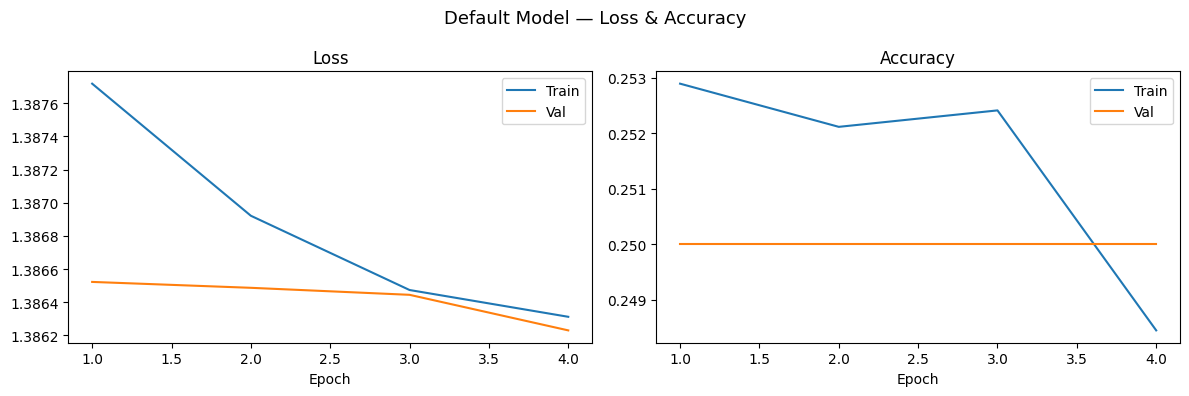

In [8]:
# ── 2. Model Definition ───────────────────────────────────────────────────────
#
# Architecture choice: GRU
# Reason: GRU has fewer parameters than LSTM (no separate cell state), trains
# faster, and achieves comparable accuracy on mid-sized text classification tasks.
# For sentence-level classification, the extra memory gate of LSTM rarely helps.

class TextRNN(nn.Module):
    """
    GRU-based text classifier.
    Layers:
      1. Embedding
      2. GRU (stacked, bidirectional optional)
      3. Dropout
      4. Fully-connected classifier
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers,
                 num_classes, dropout, bidirectional=False, pad_idx=0):
        super().__init__()
        self.bidirectional = bidirectional
        self.hidden_size   = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.rnn = nn.GRU(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = bidirectional
        )

        self.dropout = nn.Dropout(dropout)
        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(fc_in, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.dropout(self.embedding(x))          # (batch, seq, embed_dim)
        _, hidden = self.rnn(emb)                      # hidden: (num_layers*D, batch, H)

        if self.bidirectional:
            # Concatenate last hidden states of forward and backward passes
            out = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, 2H)
        else:
            out = hidden[-1]                           # (batch, H)

        out = self.dropout(out)
        return self.fc(out)                            # (batch, num_classes)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── 3. Training & Evaluation helpers ──────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, clip=1.0):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        # Gradient clipping to prevent exploding gradients in RNNs
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)
            total_loss += loss.item() * y.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / total, correct / total


def train_model(config, train_loader, val_loader, max_seq_len,
                num_epochs=10, patience=3, verbose=True):
    """
    Full training loop with early stopping.
    Returns trained model and history dict.
    """
    model = TextRNN(
        vocab_size   = VOCAB_SIZE,
        embed_dim    = config['embed_dim'],
        hidden_size  = config['hidden_size'],
        num_layers   = config['num_layers'],
        num_classes  = 4,
        dropout      = config['dropout'],
        bidirectional= config.get('bidirectional', False)
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()
    # Learning rate scheduler: reduce on plateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state, no_improve = 0.0, None, 0

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if verbose:
            print(f"  Epoch {epoch:2d} | "
                  f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
                  f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

        # Early stopping: save best weights
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch} (patience={patience})")
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return model, history


def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Default model: train and inspect ─────────────────────────────────────────
DEFAULT_CONFIG = {
    'embed_dim':   100,
    'hidden_size': 128,
    'num_layers':  2,
    'dropout':     0.3,
    'lr':          1e-3,
}

print("=" * 60)
print("Default model architecture")
print("=" * 60)
_demo = TextRNN(VOCAB_SIZE, DEFAULT_CONFIG['embed_dim'],
                DEFAULT_CONFIG['hidden_size'], DEFAULT_CONFIG['num_layers'],
                4, DEFAULT_CONFIG['dropout'])
print(_demo)
print(f"\nTrainable parameters: {count_parameters(_demo):,}")

print("\n--- Training default model ---")
default_model, default_history = train_model(
    DEFAULT_CONFIG, train_loader, val_loader,
    max_seq_len=MAX_SEQ_LEN, num_epochs=15, patience=3
)
plot_history(default_history, title='Default Model — Loss & Accuracy')

## Step 4: Hyperparameter Tuning (Manual)

We vary **hidden_size** and **max_sequence_length** independently while keeping all other hyperparameters fixed.

Experiment A: varying hidden_size  (seq_len=150 fixed)

hidden_size = 64
  Epoch  1 | Train Loss: 1.3875  Acc: 0.2502 | Val Loss: 1.3868  Acc: 0.2500
  Epoch  2 | Train Loss: 1.3867  Acc: 0.2526 | Val Loss: 1.3864  Acc: 0.2500
  Epoch  3 | Train Loss: 1.3864  Acc: 0.2533 | Val Loss: 1.3874  Acc: 0.2500
  Epoch  4 | Train Loss: 1.3862  Acc: 0.2507 | Val Loss: 1.3860  Acc: 0.2507
  Epoch  5 | Train Loss: 1.3850  Acc: 0.2463 | Val Loss: 1.4075  Acc: 0.2500
  Epoch  6 | Train Loss: 1.3842  Acc: 0.2523 | Val Loss: 1.3865  Acc: 0.2520
  Epoch  7 | Train Loss: 1.3318  Acc: 0.3000 | Val Loss: 1.0692  Acc: 0.4933
  Epoch  8 | Train Loss: 0.8685  Acc: 0.6113 | Val Loss: 0.6593  Acc: 0.7473
  Epoch  9 | Train Loss: 0.5847  Acc: 0.7789 | Val Loss: 0.4761  Acc: 0.8267
  Epoch 10 | Train Loss: 0.4396  Acc: 0.8424 | Val Loss: 0.4415  Acc: 0.8530
  Epoch 11 | Train Loss: 0.3678  Acc: 0.8740 | Val Loss: 0.3735  Acc: 0.8687
  Epoch 12 | Train Loss: 0.3214  Acc: 0.8892 | Val Loss: 0.3516  Acc: 0.8827

hi

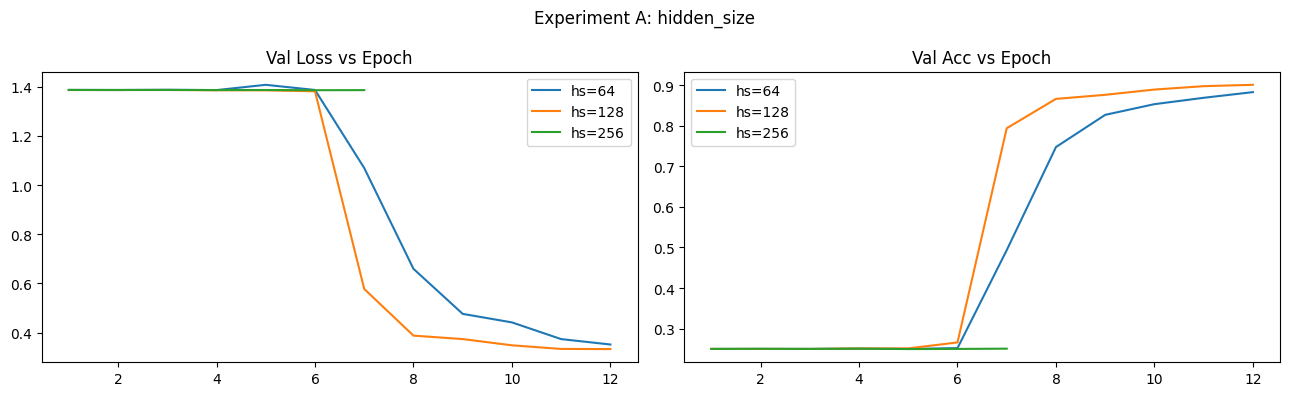


Experiment B: varying max_seq_len  (hidden_size=128 fixed)

max_seq_len = 50
  Epoch  1 | Train Loss: 1.0670  Acc: 0.5049 | Val Loss: 0.6423  Acc: 0.7530
  Epoch  2 | Train Loss: 0.5740  Acc: 0.7857 | Val Loss: 0.4519  Acc: 0.8433
  Epoch  3 | Train Loss: 0.4131  Acc: 0.8533 | Val Loss: 0.3721  Acc: 0.8757
  Epoch  4 | Train Loss: 0.3394  Acc: 0.8848 | Val Loss: 0.3437  Acc: 0.8870
  Epoch  5 | Train Loss: 0.2881  Acc: 0.9019 | Val Loss: 0.3402  Acc: 0.8907
  Epoch  6 | Train Loss: 0.2518  Acc: 0.9134 | Val Loss: 0.3251  Acc: 0.8883
  Epoch  7 | Train Loss: 0.2244  Acc: 0.9251 | Val Loss: 0.3329  Acc: 0.8943
  Epoch  8 | Train Loss: 0.2040  Acc: 0.9297 | Val Loss: 0.3294  Acc: 0.8953
  Epoch  9 | Train Loss: 0.1826  Acc: 0.9381 | Val Loss: 0.3398  Acc: 0.8943
  Epoch 10 | Train Loss: 0.1510  Acc: 0.9491 | Val Loss: 0.3446  Acc: 0.9020
  Epoch 11 | Train Loss: 0.1340  Acc: 0.9550 | Val Loss: 0.3522  Acc: 0.9020
  Epoch 12 | Train Loss: 0.1267  Acc: 0.9574 | Val Loss: 0.3639  Acc: 0.895

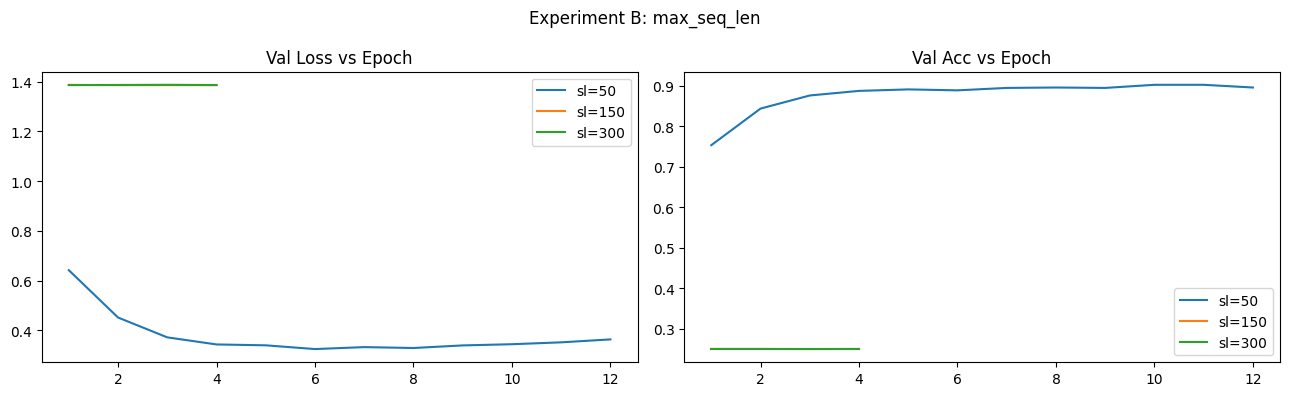


Best hidden_size   : 128
Best max_seq_len   : 50


In [9]:
# ── 4. Manual Hyperparameter Search ──────────────────────────────────────────
#
# Rule: change ONE hyperparameter at a time; keep the rest fixed at defaults.

FIXED = {
    'embed_dim':   100,
    'hidden_size': 128,
    'num_layers':  2,
    'dropout':     0.3,
    'lr':          1e-3,
}
FIXED_SEQ_LEN = 150


# ── Helper: build loaders for a given max_seq_len ─────────────────────────────
def make_loaders(max_seq_len, batch_size=64):
    tr_enc = encode_dataset(train_tokens, vocab, max_seq_len)
    vl_enc = encode_dataset(val_tokens,   vocab, max_seq_len)
    tr_l = DataLoader(NewsDataset(tr_enc, train_df['label'].tolist()),
                      batch_size=batch_size, shuffle=True)
    vl_l = DataLoader(NewsDataset(vl_enc, val_df['label'].tolist()),
                      batch_size=batch_size, shuffle=False)
    return tr_l, vl_l


# ── 4a-i. Vary hidden_size ─────────────────────────────────────────────────────
print("=" * 60)
print("Experiment A: varying hidden_size  (seq_len=150 fixed)")
print("=" * 60)

hidden_sizes   = [64, 128, 256]
hs_results     = []
hs_histories   = {}

tr_l, vl_l = make_loaders(FIXED_SEQ_LEN)

for hs in hidden_sizes:
    cfg = {**FIXED, 'hidden_size': hs}
    print(f"\nhidden_size = {hs}")
    model, hist = train_model(cfg, tr_l, vl_l, FIXED_SEQ_LEN,
                              num_epochs=12, patience=3, verbose=True)
    best_val_acc = max(hist['val_acc'])
    params       = count_parameters(model)
    hs_results.append({'hidden_size': hs, 'best_val_acc': best_val_acc,
                       'epochs_run': len(hist['val_acc']), 'params': params})
    hs_histories[hs] = hist

hs_df = pd.DataFrame(hs_results)
print("\nHidden Size Experiment Results:")
print(hs_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hs, hist in hs_histories.items():
    e = range(1, len(hist['val_acc']) + 1)
    axes[0].plot(e, hist['val_loss'], label=f'hs={hs}')
    axes[1].plot(e, hist['val_acc'],  label=f'hs={hs}')
axes[0].set_title('Val Loss vs Epoch'); axes[0].legend()
axes[1].set_title('Val Acc vs Epoch');  axes[1].legend()
fig.suptitle('Experiment A: hidden_size')
plt.tight_layout(); plt.show()


# ── 4a-ii. Vary max_sequence_length ───────────────────────────────────────────
print("\n" + "=" * 60)
print("Experiment B: varying max_seq_len  (hidden_size=128 fixed)")
print("=" * 60)

seq_lengths  = [50, 150, 300]
sl_results   = []
sl_histories = {}

for sl in seq_lengths:
    cfg = {**FIXED}           # hidden_size kept at default 128
    tr_l_sl, vl_l_sl = make_loaders(sl)
    print(f"\nmax_seq_len = {sl}")
    model, hist = train_model(cfg, tr_l_sl, vl_l_sl, sl,
                              num_epochs=12, patience=3, verbose=True)
    best_val_acc = max(hist['val_acc'])
    params       = count_parameters(model)   # same model architecture
    sl_results.append({'max_seq_len': sl, 'best_val_acc': best_val_acc,
                       'epochs_run': len(hist['val_acc']), 'params': params})
    sl_histories[sl] = hist

sl_df = pd.DataFrame(sl_results)
print("\nSequence Length Experiment Results:")
print(sl_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sl, hist in sl_histories.items():
    e = range(1, len(hist['val_acc']) + 1)
    axes[0].plot(e, hist['val_loss'], label=f'sl={sl}')
    axes[1].plot(e, hist['val_acc'],  label=f'sl={sl}')
axes[0].set_title('Val Loss vs Epoch'); axes[0].legend()
axes[1].set_title('Val Acc vs Epoch');  axes[1].legend()
fig.suptitle('Experiment B: max_seq_len')
plt.tight_layout(); plt.show()


# ── 4d. Best hyperparameter combination ───────────────────────────────────────
#
# Choose best hidden_size and best seq_len based on val_acc from the experiments
best_hs = hs_df.loc[hs_df['best_val_acc'].idxmax(), 'hidden_size']
best_sl = sl_df.loc[sl_df['best_val_acc'].idxmax(), 'max_seq_len']

print("\n" + "=" * 60)
print(f"Best hidden_size   : {best_hs}")
print(f"Best max_seq_len   : {best_sl}")
print("=" * 60)

BEST_CONFIG = {**FIXED, 'hidden_size': int(best_hs)}
BEST_SEQ_LEN = int(best_sl)

## Step 5: Final Model Evaluation + Bonus (BiGRU vs GRU)

Training best (unidirectional GRU) model ...
  Epoch  1 | Train Loss: 1.0632  Acc: 0.5130 | Val Loss: 0.6146  Acc: 0.7793
  Epoch  2 | Train Loss: 0.5548  Acc: 0.8003 | Val Loss: 0.3965  Acc: 0.8607
  Epoch  3 | Train Loss: 0.4107  Acc: 0.8563 | Val Loss: 0.3391  Acc: 0.8867
  Epoch  4 | Train Loss: 0.3422  Acc: 0.8812 | Val Loss: 0.3339  Acc: 0.8903
  Epoch  5 | Train Loss: 0.2912  Acc: 0.9007 | Val Loss: 0.3104  Acc: 0.8933
  Epoch  6 | Train Loss: 0.2571  Acc: 0.9127 | Val Loss: 0.3138  Acc: 0.8987
  Epoch  7 | Train Loss: 0.2274  Acc: 0.9241 | Val Loss: 0.3239  Acc: 0.8977
  Epoch  8 | Train Loss: 0.2021  Acc: 0.9324 | Val Loss: 0.3129  Acc: 0.9067
  Epoch  9 | Train Loss: 0.1647  Acc: 0.9436 | Val Loss: 0.3229  Acc: 0.9030
  Epoch 10 | Train Loss: 0.1523  Acc: 0.9484 | Val Loss: 0.3237  Acc: 0.9073
  Epoch 11 | Train Loss: 0.1421  Acc: 0.9511 | Val Loss: 0.3366  Acc: 0.9037
  Epoch 12 | Train Loss: 0.1236  Acc: 0.9576 | Val Loss: 0.3564  Acc: 0.9067
  Epoch 13 | Train Loss: 0.1169

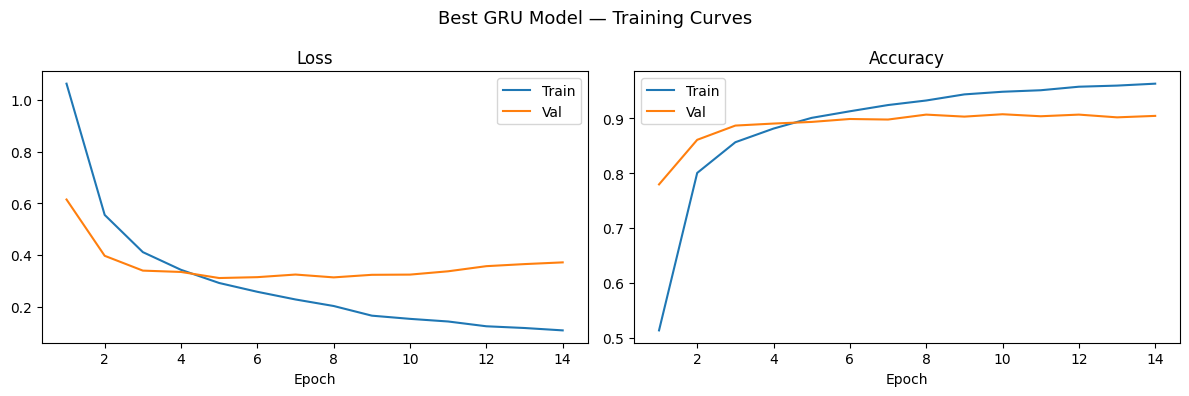


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

       World       0.90      0.89      0.90       500
      Sports       0.94      0.96      0.95       500
    Business       0.86      0.82      0.84       500
    Sci/Tech       0.84      0.87      0.85       500

    accuracy                           0.89      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.88      0.89      0.88      2000



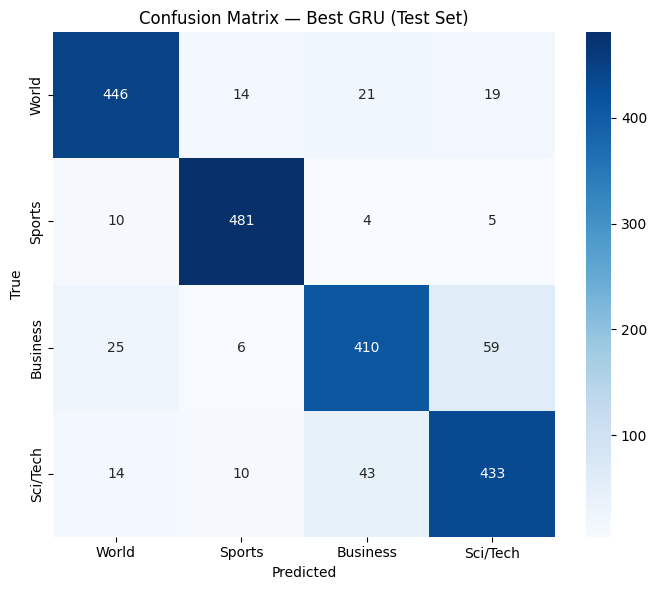


=== Correctly Classified Examples ===
  Text    : Seagate claims storage record Seagate claims to have broken the record for the most storage on a sin ...
  True: Sci/Tech  |  Pred: Sci/Tech

  Text    : British Terror Suspects Make First Court Appearance  LONDON (Reuters) - British terror suspects char ...
  True: World  |  Pred: World

  Text    : Oracle Profit Rises on Software Demand  SAN FRANCISCO (Reuters) - Oracle Corp. on Tuesday reported   ...
  True: Business  |  Pred: Business

  Text    : Dunn Sets Major League Strikeouts Record (AP) AP - Cincinnati Reds slugger Adam Dunn set the major l ...
  True: Sports  |  Pred: Sports

=== Misclassified Examples ===
  Text    : Bridges Loom as Cash Cow That Nobody Dares to Milk There they stand, glinting in the sun, hanging of ...
  True: Business  |  Pred: World

  Text    : Japan's comics retool the art Animation in America once meant Mickey Mouse and Winnie the Pooh. Thes ...
  True: Business  |  Pred: World

  Text    : Japan Won'

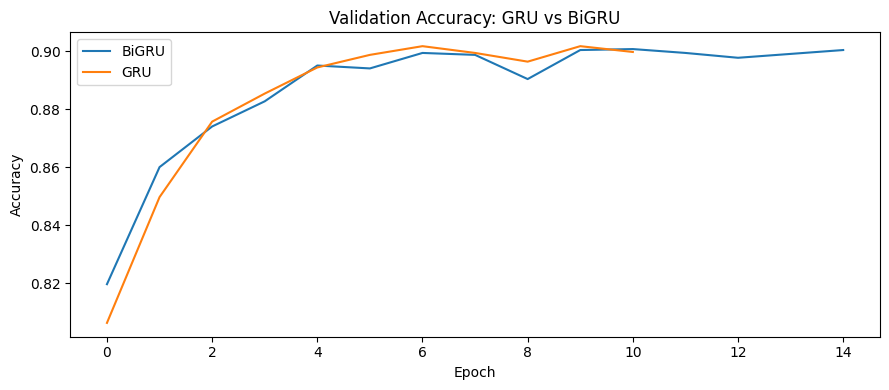

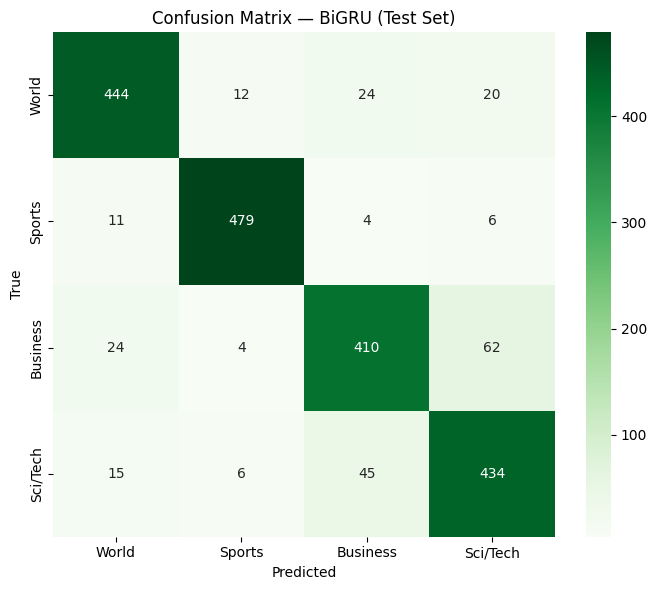


Cases where BiGRU correct but GRU wrong: 65
  Text : Japan's comics retool the art Animation in America once meant Mickey Mouse and Winnie the Pooh. These days, it ...
  True: Business  |  GRU: Sci/Tech  |  BiGRU: Business

  Text : Japan Won't Have U.S. Beef Anytime Soon (Reuters) Reuters - Japan's lucrative market for U.S.\beef, ruptured b ...
  True: World  |  GRU: Sci/Tech  |  BiGRU: World

  Text : Pharma Groups Work on EPC Issues Sept. 30, 2004Reacting to calls from pharmaceutical retailers, distributors a ...
  True: Sci/Tech  |  GRU: Business  |  BiGRU: Sci/Tech


All done!


In [10]:
# ── 5. Final Evaluation on Test Set ──────────────────────────────────────────

# Re-encode with best seq length
tr_best_enc   = encode_dataset(train_tokens, vocab, BEST_SEQ_LEN)
vl_best_enc   = encode_dataset(val_tokens,   vocab, BEST_SEQ_LEN)
te_best_enc   = encode_dataset(test_tokens,  vocab, BEST_SEQ_LEN)

tr_best_loader = DataLoader(NewsDataset(tr_best_enc, train_df['label'].tolist()),
                            batch_size=64, shuffle=True)
vl_best_loader = DataLoader(NewsDataset(vl_best_enc, val_df['label'].tolist()),
                            batch_size=64, shuffle=False)
te_best_loader = DataLoader(NewsDataset(te_best_enc, test_df['label'].tolist()),
                            batch_size=64, shuffle=False)

print("Training best (unidirectional GRU) model ...")
best_model, best_history = train_model(
    BEST_CONFIG, tr_best_loader, vl_best_loader,
    max_seq_len=BEST_SEQ_LEN, num_epochs=20, patience=4, verbose=True
)
plot_history(best_history, title='Best GRU Model — Training Curves')


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            preds = model(x).argmax(1).cpu().tolist()
            all_preds  += preds
            all_labels += y.tolist()
    return all_labels, all_preds


# ── 5a-b. Metrics per class ───────────────────────────────────────────────────
labels_true, labels_pred = get_predictions(best_model, te_best_loader)

print("\n=== Classification Report (Test Set) ===")
print(classification_report(labels_true, labels_pred, target_names=CLASS_NAMES))

# ── 5c. Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(labels_true, labels_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Best GRU (Test Set)')
plt.tight_layout(); plt.show()

# ── 5d. Sample correct and incorrect predictions ──────────────────────────────
test_texts = [str(row['title']) + ' ' + str(row['description'])
              for _, row in test_df.iterrows()]

correct_idx   = [i for i, (t, p) in enumerate(zip(labels_true, labels_pred)) if t == p]
incorrect_idx = [i for i, (t, p) in enumerate(zip(labels_true, labels_pred)) if t != p]

print("\n=== Correctly Classified Examples ===")
for i in correct_idx[:4]:
    print(f"  Text    : {test_texts[i][:100]} ...")
    print(f"  True: {CLASS_NAMES[labels_true[i]]}  |  Pred: {CLASS_NAMES[labels_pred[i]]}\n")

print("=== Misclassified Examples ===")
for i in incorrect_idx[:4]:
    print(f"  Text    : {test_texts[i][:100]} ...")
    print(f"  True: {CLASS_NAMES[labels_true[i]]}  |  Pred: {CLASS_NAMES[labels_pred[i]]}\n")


# ── BONUS: Bidirectional GRU ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("BONUS: BiGRU vs GRU comparison")
print("=" * 60)
#
# Explanation:
# - Unidirectional GRU processes tokens left→right; the final hidden state
#   captures mostly the end of the sequence.
# - BiGRU runs two GRUs (forward + backward) and concatenates their hidden
#   states → the representation captures context from BOTH directions.
# - For classification, BiGRU gives a richer sentence representation.
# Trade-offs: ~2x parameters, ~2x training time, slightly larger memory footprint.

BIGRU_CONFIG = {**BEST_CONFIG, 'bidirectional': True}

print("\nTraining BiGRU model ...")
t0 = time.time()
bigru_model, bigru_history = train_model(
    BIGRU_CONFIG, tr_best_loader, vl_best_loader,
    max_seq_len=BEST_SEQ_LEN, num_epochs=20, patience=4, verbose=True
)
bigru_time = time.time() - t0

t0 = time.time()
gru_model2, gru_history2 = train_model(
    BEST_CONFIG, tr_best_loader, vl_best_loader,
    max_seq_len=BEST_SEQ_LEN, num_epochs=20, patience=4, verbose=False
)
gru_time = time.time() - t0

# Metrics
labels_true_bi, labels_pred_bi = get_predictions(bigru_model, te_best_loader)
labels_true_u,  labels_pred_u  = get_predictions(gru_model2,  te_best_loader)

print("\n=== BiGRU Classification Report ===")
print(classification_report(labels_true_bi, labels_pred_bi, target_names=CLASS_NAMES))

# Comparison table
comp_df = pd.DataFrame([
    {
        'Model'         : 'GRU (unidirectional)',
        'Params'        : count_parameters(gru_model2),
        'Test Accuracy' : accuracy_score(labels_true_u, labels_pred_u),
        'Train Time (s)': round(gru_time, 1),
    },
    {
        'Model'         : 'BiGRU (bidirectional)',
        'Params'        : count_parameters(bigru_model),
        'Test Accuracy' : accuracy_score(labels_true_bi, labels_pred_bi),
        'Train Time (s)': round(bigru_time, 1),
    },
])
print("\n=== GRU vs BiGRU Comparison ===")
print(comp_df.to_string(index=False))

# Side-by-side accuracy curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bigru_history['val_acc'], label='BiGRU')
ax.plot(gru_history2['val_acc'],  label='GRU')
ax.set_title('Validation Accuracy: GRU vs BiGRU')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); plt.tight_layout(); plt.show()

# Confusion matrix for BiGRU
cm_bi = confusion_matrix(labels_true_bi, labels_pred_bi)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_bi, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — BiGRU (Test Set)')
plt.tight_layout(); plt.show()

# ── Sample analysis: does bidirectionality help? ──────────────────────────────
# Find cases where BiGRU is correct but GRU is wrong
bigru_wins = [
    i for i, (t, pu, pb) in enumerate(zip(labels_true_bi, labels_pred_u, labels_pred_bi))
    if t == pb and t != pu
]
print(f"\nCases where BiGRU correct but GRU wrong: {len(bigru_wins)}")
for i in bigru_wins[:3]:
    print(f"  Text : {test_texts[i][:110]} ...")
    print(f"  True: {CLASS_NAMES[labels_true_bi[i]]}  |  GRU: {CLASS_NAMES[labels_pred_u[i]]}  |  BiGRU: {CLASS_NAMES[labels_pred_bi[i]]}\n")

print("\nAll done!")